In [1]:
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
import os
import base64
import io
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
import torch
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm


c:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\pro_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model.to(device)
print("Using device:", device)





Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Using device: cuda


In [3]:



import json

with open("fruit_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)
Data = [Document(page_content=d["page_content"], metadata=d["metadata"]) for d in data]

In [4]:
Data

[Document(metadata={'fruitname': 'apple'}, page_content='One of the most popular fruits, apples are chock-full of nutrition.\n\nThey’re rich in both soluble and insoluble fiber, such as pectin, hemicellulose, and cellulose. These help you manage your blood sugar levels, promote good digestion, and support gut and heart health.\n\nIn addition, they’re a good source of vitamin C and plant polyphenols, which are disease-fighting compounds found in plants. In fact, consuming apples regularly may lower your risk of heart disease, stroke, cancer, overweight, obesity, and neurological disorders.\n\nNote that most of the polyphenols in apples are located just below the skin, so be sure to eat it to reap the greatest benefits.'),
 Document(metadata={'fruitname': 'blueberry'}, page_content='Blueberries are well known for their antioxidant and anti-inflammatory properties.\n\nIn particular, they’re high in anthocyanin, a plant pigment and flavonoid that gives blueberries their characteristic blue

In [5]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=600,      
    chunk_overlap=200,  
    separators=["\n\n", "\n", ".", "!", "?", ",", " ", ""]
)


split_docs = text_splitter.split_documents(Data)




In [6]:


print(f"Original docs: {len(Data)}")
print(f"Split docs: {len(split_docs)}")

for docs in split_docs[:]:
    print(docs.page_content[:])  
    print(docs.metadata)
    print("\n---\n")

Original docs: 15
Split docs: 22
One of the most popular fruits, apples are chock-full of nutrition.

They’re rich in both soluble and insoluble fiber, such as pectin, hemicellulose, and cellulose. These help you manage your blood sugar levels, promote good digestion, and support gut and heart health.

In addition, they’re a good source of vitamin C and plant polyphenols, which are disease-fighting compounds found in plants. In fact, consuming apples regularly may lower your risk of heart disease, stroke, cancer, overweight, obesity, and neurological disorders.
{'fruitname': 'apple'}

---

Note that most of the polyphenols in apples are located just below the skin, so be sure to eat it to reap the greatest benefits.
{'fruitname': 'apple'}

---

Blueberries are well known for their antioxidant and anti-inflammatory properties.

In particular, they’re high in anthocyanin, a plant pigment and flavonoid that gives blueberries their characteristic blue-purple color. This compound helps figh

In [7]:
def get_clip_text_embedding(text):
 
    inputs = clip_processor(text=text, return_tensors="pt", padding=True, truncation=True)
 
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        text_embeds = clip_model.get_text_features(**inputs)

    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
   
    return text_embeds.cpu().numpy()[0]


test_text = "Apples are rich in fiber and vitamins."
embedding = get_clip_text_embedding(test_text)

print("Embedding shape:", embedding.shape)
print("First 5 values:", embedding[:5])

Embedding shape: (512,)
First 5 values: [ 0.00499238  0.06308762  0.04978157  0.00776481 -0.01281392]


In [8]:
embeddings_store=[]

In [9]:


for doc in tqdm(split_docs, desc="Embedding text chunks"):
    emb = get_clip_text_embedding(doc.page_content)
    embeddings_store.append({
        "embedding": emb,
        "metadata": doc.metadata,
        "text": doc.page_content
    })

Embedding text chunks: 100%|██████████| 22/22 [00:03<00:00,  7.23it/s]


In [10]:
import numpy as np

vectors = np.array([item["embedding"] for item in embeddings_store]).astype("float32")

print("Shape:", vectors.shape) 
print("Dtype:", vectors.dtype)


Shape: (22, 512)
Dtype: float32


In [11]:

from PIL import Image


In [12]:
def embed_image(image_data):
  
    if isinstance(image_data, str):  
        image = Image.open(image_data).convert("RGB")
    else:  
        image = image_data
    
   
    inputs = clip_processor(images=image, return_tensors="pt").to(device)
    
    with torch.no_grad():
        features = clip_model.get_image_features(**inputs)
      
        features = features / features.norm(dim=-1, keepdim=True)
    
    return features.squeeze().cpu().numpy()




In [13]:
vectors = np.array([item["embedding"] for item in embeddings_store]).astype("float32")

In [14]:
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_embeddings(
    text_embeddings=[(item["text"], item["embedding"]) for item in embeddings_store],
    embedding=None, 
    metadatas=[item["metadata"] for item in embeddings_store]
)


`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [15]:
def retrieve_multimodal(image_path: str, k: int = 5):

   
    query_embedding = embed_image(image_path).astype("float32")


    results = vector_store.similarity_search_by_vector(
        embedding=query_embedding,
        k=k
    )

    return results

Lets try retrival with apple

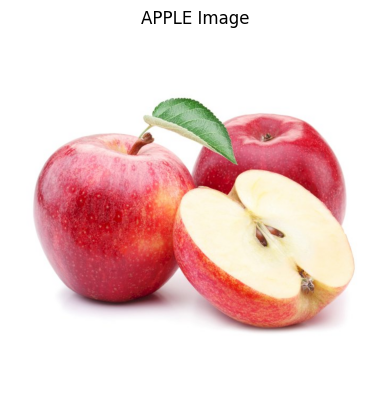

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\APPLE.jpg"

img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')  
plt.title("APPLE Image")
plt.show()


In [22]:
results = retrieve_multimodal(
    r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\APPLE.jpg",
    k=1
)

for i, doc in enumerate(results, 1):
    print(f"\nResult {i}")
    print("Content:", doc.page_content)
    print("Metadata:", doc.metadata)


Result 1
Content: One of the most popular fruits, apples are chock-full of nutrition.

They’re rich in both soluble and insoluble fiber, such as pectin, hemicellulose, and cellulose. These help you manage your blood sugar levels, promote good digestion, and support gut and heart health.

In addition, they’re a good source of vitamin C and plant polyphenols, which are disease-fighting compounds found in plants. In fact, consuming apples regularly may lower your risk of heart disease, stroke, cancer, overweight, obesity, and neurological disorders.
Metadata: {'fruitname': 'apple'}


Now with mango

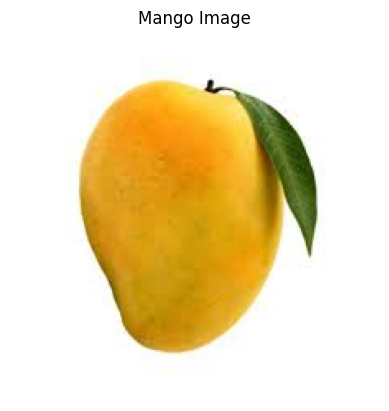

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\Mango.jpg"

img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')  
plt.title("Mango Image")
plt.show()

In [21]:
results = retrieve_multimodal(
    r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\Mango.jpg",
    k=1
)

for i, doc in enumerate(results, 1):
    print(f"\nResult {i}")
    print("Content:", doc.page_content)
    print("Metadata:", doc.metadata)


Result 1
Content: Known as the “king of fruits,” mangoes are an excellent source of potassium, folate, fiber, and vitamins A, C, B6, E, and K. They’re also rich in numerous plant polyphenols that have antioxidant and anti-inflammatory properties.

In particular, mangoes are high in mangiferin, a potent antioxidant. Studies have shown it may protect the body from chronic diseases, such as:

type 2 diabetes
heart disease
Alzheimer’s
Parkinson’s
certain forms of cancer

What’s more, mangoes contain fiber, which helps support regular bowel movements and aids digestive health.
Metadata: {'fruitname': 'mango'}
